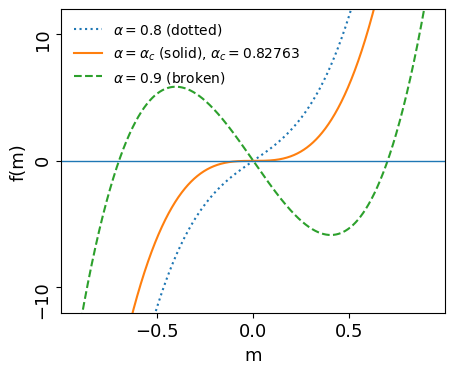

alpha_c(h=0) = 0.8276253029821987


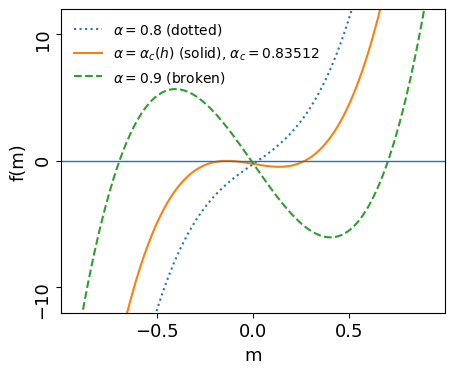

alpha_c(h=0.01) = 0.8351182404795314


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import math

# -----------------------------
# Figure 1 (separate outputs) with:
#  - x ticks: [-0.5, 0.0, 0.5]
#  - y ticks: [-20, -10, 0, 10, 20]
#  - fontsize: 15
# -----------------------------

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 10,
    "axes.labelsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 10,
})

tau = 1e2
J = 0.1
alpha1 = 0.8
alpha3 = 0.9

def a_of(alpha, tau):
    return 2.0 * ((tau / alpha**2) * (1.0 - alpha) - 1.0)

def B_of(alpha, J, tau):
    # (N-1)b = -4*(tau/alpha)*J
    return -4.0 * (tau / alpha) * J

def f_of(m, alpha, J, h, tau):
    a = a_of(alpha, tau)
    B = B_of(alpha, J, tau)
    return (a + B) * m - B * m**3 - 2.0 * (tau / alpha) * h * (1.0 - m**2)

def alpha_c_h0(J, tau):
    return (math.sqrt(tau**2 * (2.0 * J + 1.0)**2 + 4.0 * tau) - tau * (2.0 * J + 1.0)) / 2.0

def alpha_c_h_numeric(J, h, tau, lo=0.5, hi=0.999, tol=1e-12):
    def g(alpha):
        a = a_of(alpha, tau)
        B = B_of(alpha, J, tau)
        # f'(m)=0: (-3B)m^2 + 4*(tau/alpha)*h*m + (a+B)=0
        A = -3.0 * B
        Bq = 4.0 * (tau / alpha) * h
        C = (a + B)
        disc = Bq**2 - 4.0 * A * C
        if disc < 0:
            return None
        r1 = (-Bq + math.sqrt(disc)) / (2.0 * A)
        r2 = (-Bq - math.sqrt(disc)) / (2.0 * A)

        vals = []
        for m0 in (r1, r2):
            if abs(m0) <= alpha:  # constraint in the paper
                vals.append(f_of(m0, alpha, J, h, tau))
        if not vals:
            return None
        return max(vals)

    g_lo = g(lo)
    g_hi = g(hi)
    if g_lo is None: g_lo = -1.0
    if g_hi is None: g_hi = -1.0

    for _ in range(2000):
        if g_lo < 0 and g_hi > 0:
            break
        if g_hi <= 0:
            hi = (hi + 1.0) / 2.0
            g_hi = g(hi)
            if g_hi is None: g_hi = -1.0
        if g_lo >= 0:
            lo = (lo + hi) / 2.0
            g_lo = g(lo)
            if g_lo is None: g_lo = -1.0
    else:
        raise RuntimeError("Failed to bracket alpha_c(h). Try changing lo/hi.")

    for _ in range(400):
        mid = (lo + hi) / 2.0
        g_mid = g(mid)
        if g_mid is None: g_mid = -1.0
        if g_mid > 0:
            hi = mid
        else:
            lo = mid
        if abs(hi - lo) < tol:
            break
    return (lo + hi) / 2.0

# axis settings
xlim = (-1.0, 1.0)
ylim = (-12, 12)
xticks = np.arange(-0.5, 0.5 + 1e-9, 0.5)  # -0.5, 0, 0.5
yticks = np.arange(-10, 10 + 1e-9, 10)     # -20, -10, 0, 10, 20

# grid
m = np.linspace(xlim[0], xlim[1], 2000)

# -------- Left figure (h=0.0) --------
h = 0.0
alpha2 = alpha_c_h0(J, tau)

plt.figure(figsize=(5, 4))
plt.plot(m, f_of(m, alpha1, J, h, tau), ":",  label=r"$\alpha=0.8$ (dotted)")
plt.plot(m, f_of(m, alpha2, J, h, tau), "-",  label=rf"$\alpha=\alpha_c$ (solid), $\alpha_c={alpha2:.5f}$")
plt.plot(m, f_of(m, alpha3, J, h, tau), "--", label=r"$\alpha=0.9$ (broken)")
plt.axhline(0, linewidth=1)

plt.xlim(*xlim)
plt.ylim(*ylim)
plt.xticks(xticks)
plt.yticks(yticks)

plt.xlabel("m")
plt.ylabel("f(m)")
plt.legend(frameon=False)
plt.tight_layout()
plt.tick_params(axis='y', labelrotation=90) 
plt.show()

print("alpha_c(h=0) =", alpha2)

# -------- Right figure (h=0.01) --------
h = 0.001
alpha2 = alpha_c_h_numeric(J, h, tau)

plt.figure(figsize=(5, 4))
plt.plot(m, f_of(m, alpha1, J, h, tau), ":",  label=r"$\alpha=0.8$ (dotted)")
plt.plot(m, f_of(m, alpha2, J, h, tau), "-",  label=rf"$\alpha=\alpha_c(h)$ (solid), $\alpha_c={alpha2:.5f}$")
plt.plot(m, f_of(m, alpha3, J, h, tau), "--", label=r"$\alpha=0.9$ (broken)")
plt.axhline(0, linewidth=1)

plt.xlim(*xlim)
plt.ylim(*ylim)
plt.xticks(xticks)
plt.yticks(yticks)

plt.xlabel("m")
plt.ylabel("f(m)")
plt.legend(frameon=False)
plt.tight_layout()
plt.tick_params(axis='y', labelrotation=90) 
plt.show()

print("alpha_c(h=0.01) =", alpha2)


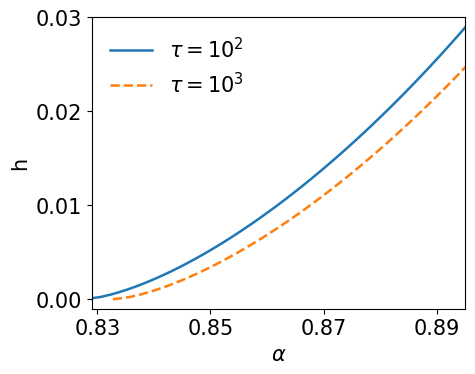

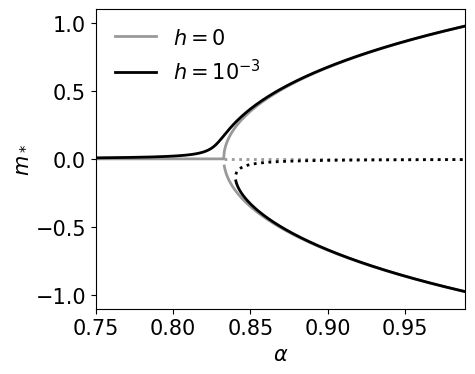

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import math

# -----------------------------
# Figure 2 (separate outputs)
#   Left : h vs alpha_c(h) for J=0.1, tau=1e2 (solid) and tau=1e3 (dashed)
#   Right: m* vs alpha for J=0.1, tau=1e3 with h=0.0 (gray) and h=1e-3 (black)
#          solid = maxima (m*), dotted = minima (m_t)
# -----------------------------

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
})

J = 0.1

def a_of(alpha, tau):
    return 2.0 * ((tau / alpha**2) * (1.0 - alpha) - 1.0)

def B_of(alpha, J, tau):
    # (N-1)b = -4*(tau/alpha)*J
    return -4.0 * (tau / alpha) * J

def f_of(m, alpha, J, h, tau):
    a = a_of(alpha, tau)
    B = B_of(alpha, J, tau)
    return (a + B) * m - B * m**3 - 2.0 * (tau / alpha) * h * (1.0 - m**2)

def alpha_c_h0(J, tau):
    return (math.sqrt(tau**2 * (2.0 * J + 1.0)**2 + 4.0 * tau) - tau * (2.0 * J + 1.0)) / 2.0

def alpha_c_h_numeric(J, h, tau, lo=0.5, hi=0.999, tol=1e-12):
    """
    h>0 のときの alpha_c(h) を数値で求める（接線条件: 局所最大値が 0 に一致）
    """
    if h == 0.0:
        return alpha_c_h0(J, tau)

    def g(alpha):
        a = a_of(alpha, tau)
        B = B_of(alpha, J, tau)

        # f'(m)=0 は二次方程式:
        # (-3B)m^2 + 4*(tau/alpha)*h*m + (a+B)=0
        A = -3.0 * B
        Bq = 4.0 * (tau / alpha) * h
        C = (a + B)

        disc = Bq**2 - 4.0 * A * C
        if disc < 0:
            return None

        r1 = (-Bq + math.sqrt(disc)) / (2.0 * A)
        r2 = (-Bq - math.sqrt(disc)) / (2.0 * A)

        vals = []
        for m0 in (r1, r2):
            if abs(m0) <= alpha:  # 制約 |m|<=alpha
                vals.append(f_of(m0, alpha, J, h, tau))

        if not vals:
            return None
        return max(vals)  # 局所最大の値（を含む方）

    g_lo = g(lo)
    g_hi = g(hi)
    if g_lo is None: g_lo = -1.0
    if g_hi is None: g_hi = -1.0

    # bracket
    for _ in range(2000):
        if g_lo < 0 and g_hi > 0:
            break
        if g_hi <= 0:
            hi = (hi + 1.0) / 2.0
            g_hi = g(hi)
            if g_hi is None: g_hi = -1.0
        if g_lo >= 0:
            lo = (lo + hi) / 2.0
            g_lo = g(lo)
            if g_lo is None: g_lo = -1.0
    else:
        raise RuntimeError("Failed to bracket alpha_c(h). Try changing lo/hi.")

    # bisection
    for _ in range(300):
        mid = 0.5 * (lo + hi)
        g_mid = g(mid)
        if g_mid is None:
            g_mid = -1.0
        if g_mid > 0:
            hi = mid
        else:
            lo = mid
        if abs(hi - lo) < tol:
            break

    return 0.5 * (lo + hi)

def cubic_coeffs(alpha, J, h, tau):
    """
    Eq.(13): (a+B)m - B m^3 - 2*(tau/alpha)*h*(1 - m^2) = 0
    -> c3*m^3 + c2*m^2 + c1*m + c0 = 0
    """
    a = a_of(alpha, tau)
    B = B_of(alpha, J, tau)
    c3 = -B
    c2 = 2.0 * (tau / alpha) * h
    c1 = (a + B)
    c0 = -2.0 * (tau / alpha) * h
    return c3, c2, c1, c0

def real_roots_in_domain(alpha, J, h, tau, imag_tol=1e-9):
    c3, c2, c1, c0 = cubic_coeffs(alpha, J, h, tau)
    roots = np.roots([c3, c2, c1, c0])

    real_roots = []
    for r in roots:
        if abs(r.imag) < imag_tol:
            rr = float(r.real)
            if (-alpha - 1e-9) <= rr <= (alpha + 1e-9):
                real_roots.append(rr)

    real_roots = np.array(sorted(real_roots))

    # merge near-duplicates
    if len(real_roots) >= 2:
        merged = [real_roots[0]]
        for x in real_roots[1:]:
            if abs(x - merged[-1]) > 1e-7:
                merged.append(x)
        real_roots = np.array(merged)

    return real_roots

def branches_m_star(alpha_grid, J, h, tau):
    """
    3根のとき: (小, 中, 大) = (max, min, max) として描く
    """
    m_max_top = np.full_like(alpha_grid, np.nan, dtype=float)
    m_max_bottom = np.full_like(alpha_grid, np.nan, dtype=float)
    m_min = np.full_like(alpha_grid, np.nan, dtype=float)

    for i, alpha in enumerate(alpha_grid):
        roots = real_roots_in_domain(alpha, J, h, tau)
        if len(roots) == 1:
            m_max_top[i] = roots[0]
        elif len(roots) == 2:
            m_min[i] = roots[0]
            m_max_top[i] = roots[1]
        elif len(roots) == 3:
            m_max_bottom[i] = roots[0]
            m_min[i] = roots[1]
            m_max_top[i] = roots[2]

    return m_max_top, m_max_bottom, m_min


# =========================
# Figure 2 (LEFT) as a single figure
# =========================
h_grid = np.linspace(0.0, 0.03, 121)

plt.figure(figsize=(5, 4))
for tau, ls, lab in [
    (1e2, "-",  r"$\tau=10^2$"),
    (1e3, "--", r"$\tau=10^3$")
]:
    alpha_cs = np.array([alpha_c_h_numeric(J, float(h), tau) for h in h_grid], dtype=float)
    plt.plot(alpha_cs, h_grid, ls, linewidth=1.8, label=lab)

plt.xlabel(r"$\alpha$")
plt.ylabel("h")
plt.xlim(0.829, 0.895)
plt.ylim(-0.001, 0.03)
plt.xticks([0.83, 0.85, 0.87, 0.89])
plt.yticks([0.00, 0.01, 0.02, 0.03])
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


# =========================
# Figure 2 (RIGHT) as a single figure
# =========================
tau_right = 1e3
alpha_min = 0.75
alpha_max = 1.0 - 1.0/tau_right
alpha_grid = np.linspace(alpha_min, alpha_max, 600)

plt.figure(figsize=(5, 4))

# h = 0.0 (gray)
m_top, m_bot, m_min_arr = branches_m_star(alpha_grid, J, h=0.0, tau=tau_right)
plt.plot(alpha_grid, m_top, color="0.6", linewidth=2.0, label=r"$h=0$")
plt.plot(alpha_grid, m_bot, color="0.6", linewidth=2.0)
plt.plot(alpha_grid, m_min_arr, color="0.6", linestyle=":", linewidth=2.0)

# h = 1e-3 (black)
m_top, m_bot, m_min_arr = branches_m_star(alpha_grid, J, h=1e-3, tau=tau_right)
plt.plot(alpha_grid, m_top, color="k", linewidth=2.0, label=r"$h=10^{-3}$")
plt.plot(alpha_grid, m_bot, color="k", linewidth=2.0)
plt.plot(alpha_grid, m_min_arr, color="k", linestyle=":", linewidth=2.0)

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$m_*$")
plt.xlim(alpha_min, alpha_max-0.01)
plt.ylim(-1.1, 1.1)
plt.xticks([0.75, 0.80, 0.85, 0.90, 0.95])
plt.yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()
